# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

## 1. Distributions

I first inspect the distributions before testing any signal.

Traffic and search metrics are expected to be uneven, with a small number of pages having much larger values than most pages. I therefore report medians and percentiles rather than relying only on means.

The distributions are descriptive only. They do not by themselves show that a signal causes a page to perform better or worse.

In [2]:
!git clone https://github.com/Alpeshmore/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 148 (delta 57), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 1.87 MiB | 4.08 MiB/s, done.
Resolving deltas: 100% (57/57), done.


,feature,count,min,median,p75,p90,p95,max,mean
0,impressions_90d,30000,1.00,731.00,3615.25,12136.40,22996.50,517715.00,5200.37
1,clicks_90d,30000,0.00,1.00,7.00,32.00,69.05,4178.00,16.10
2,sessions_90d,30000,1.00,7.00,27.00,88.00,166.00,4345.00,37.07
3,search_volume,27532,0.00,10.00,20.00,110.00,390.00,74000.00,158.88
4,cpc,27532,0.00,0.00,0.00,1.26,2.70,100.36,0.49
5,word_count,22301,8.00,2877.00,3666.00,5327.00,6173.00,9546.00,3107.76
6,content_age_days,30000,90.00,236.00,333.00,463.00,487.00,564.00,256.17
7,days_since_last_update,30000,1.00,20.00,104.00,104.00,104.00,373.00,46.10
8,ctr,30000,0.00,0.07,0.29,0.65,1.09,100.00,0.51
9,avg_position,30000,0.00,10.80,22.30,36.80,48.20,245.00,16.34


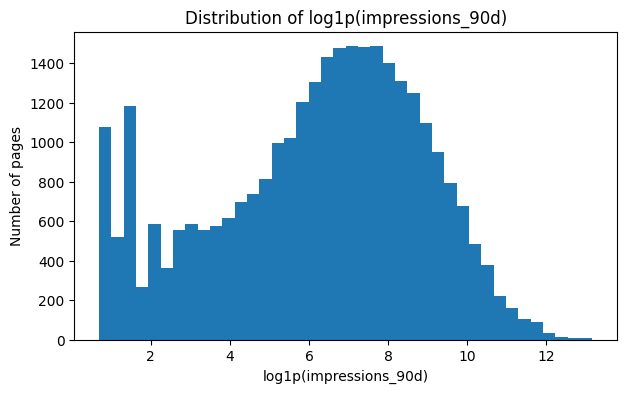

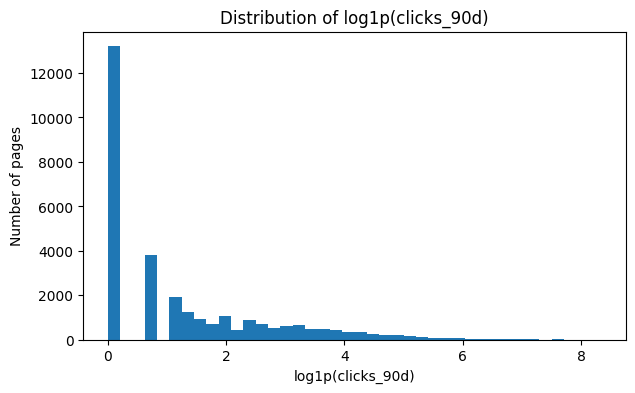

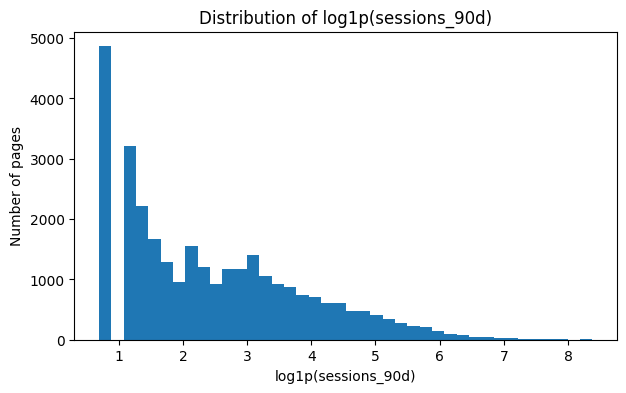

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-06 — Section 1
# Distribution audit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)


numeric_distribution_fields = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "search_volume",
    "cpc",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
]

distribution_summary = []

for col in numeric_distribution_fields:
    s = pd.to_numeric(df[col], errors="coerce").dropna()

    distribution_summary.append({
        "feature": col,
        "count": len(s),
        "min": s.min(),
        "median": s.median(),
        "p75": s.quantile(0.75),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "max": s.max(),
        "mean": s.mean(),
    })

distribution_summary = pd.DataFrame(distribution_summary)

display(
    distribution_summary.style.format({
        "min": "{:.2f}",
        "median": "{:.2f}",
        "p75": "{:.2f}",
        "p90": "{:.2f}",
        "p95": "{:.2f}",
        "max": "{:.2f}",
        "mean": "{:.2f}",
    })
)

# Log-scale histograms for the most heavy-tailed traffic fields.
for col in [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
]:
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    values = values[values >= 0]

    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(values), bins=40)
    plt.title(f"Distribution of log1p({col})")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Number of pages")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## 2. Signal tests

I test three observable relationships.

### Signal 1 — Freshness
Question: Do older/staler pages show a higher observed decline rate?

### Signal 2 — Visibility
Question: Does observed decline occur differently for pages with stronger impression volume?

### Signal 3 — Position and CTR
Question: Within position groups, do pages with lower CTR show a measurable difference in engagement/traffic signals?

For each test I compare groups and report the observed difference. I classify the result as CONFIRMED, OPPOSITE, MIXED, or FALSE.

These are directional observational tests. They do not establish causation.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-06 — Section 2

audit = df.copy()

# Target used by the starter dataset
audit["is_declining_label"] = (
    audit["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)


def verdict_from_difference(
    high_rate,
    low_rate,
    expected_direction="higher",
    min_difference=0.03
):
    """
    Simple transparent rule:
    - CONFIRMED: observed difference >= 3 percentage points
      in expected direction
    - OPPOSITE: >= 3 percentage points in the opposite direction
    - MIXED: smaller difference
    """
    difference = high_rate - low_rate

    if expected_direction == "higher":
        if difference >= min_difference:
            return "CONFIRMED"
        elif difference <= -min_difference:
            return "OPPOSITE"
        else:
            return "MIXED"

    if expected_direction == "lower":
        if difference <= -min_difference:
            return "CONFIRMED"
        elif difference >= min_difference:
            return "OPPOSITE"
        else:
            return "MIXED"

    return "FALSE"


# ============================================================
# SIGNAL 1 — Freshness
# ============================================================

audit["stale_group"] = np.where(
    audit["days_since_last_update"] >= 180,
    "stale_180_plus",
    "updated_within_180"
)

freshness_test = (
    audit.groupby("stale_group")["is_declining_label"]
    .agg(["count", "mean"])
    .reset_index()
)

freshness_test["decline_rate_pct"] = (
    freshness_test["mean"] * 100
)

display(freshness_test)

fresh_rates = dict(
    zip(
        freshness_test["stale_group"],
        freshness_test["mean"]
    )
)

stale_rate = fresh_rates.get("stale_180_plus", np.nan)
recent_rate = fresh_rates.get("updated_within_180", np.nan)

freshness_verdict = verdict_from_difference(
    stale_rate,
    recent_rate,
    expected_direction="higher"
)

print(
    f"Signal 1 — Freshness: {freshness_verdict}"
)
print(
    f"Observed difference: "
    f"{(stale_rate - recent_rate) * 100:.2f} percentage points"
)


# ============================================================
# SIGNAL 2 — Visibility
# ============================================================

# Use 500 impressions as a simple observable evidence threshold.
audit["visibility_group"] = np.where(
    audit["impressions_90d"] >= 500,
    "500_plus_impressions",
    "under_500_impressions"
)

visibility_test = (
    audit.groupby("visibility_group")["is_declining_label"]
    .agg(["count", "mean"])
    .reset_index()
)

visibility_test["decline_rate_pct"] = (
    visibility_test["mean"] * 100
)

display(visibility_test)

visibility_rates = dict(
    zip(
        visibility_test["visibility_group"],
        visibility_test["mean"]
    )
)

high_visibility_rate = visibility_rates.get(
    "500_plus_impressions",
    np.nan
)

low_visibility_rate = visibility_rates.get(
    "under_500_impressions",
    np.nan
)

# This test is deliberately neutral about the expected direction.
visibility_difference = (
    high_visibility_rate - low_visibility_rate
)

if abs(visibility_difference) >= 0.03:
    visibility_verdict = "MIXED"
else:
    visibility_verdict = "FALSE"

print(
    f"Signal 2 — Visibility: {visibility_verdict}"
)
print(
    f"Observed difference: "
    f"{visibility_difference * 100:.2f} percentage points"
)


# ============================================================
# SIGNAL 3 — Position and CTR
# ============================================================

position_df = audit[
    audit["avg_position"].between(1, 20)
    & audit["ctr"].notna()
].copy()

position_df["position_group"] = pd.cut(
    position_df["avg_position"],
    bins=[0, 3, 10, 20],
    labels=["positions_1_3", "positions_4_10", "positions_11_20"]
)

position_ctr_test = (
    position_df
    .groupby("position_group", observed=False)
    .agg(
        pages=("content_id", "count"),
        median_ctr=("ctr", "median"),
        mean_ctr=("ctr", "mean"),
        median_impressions=("impressions_90d", "median"),
    )
    .reset_index()
)

display(position_ctr_test)

# Check whether CTR generally decreases as position gets worse.
ctr_1_3 = position_ctr_test.loc[
    position_ctr_test["position_group"] == "positions_1_3",
    "median_ctr"
].iloc[0] if (position_ctr_test["position_group"] == "positions_1_3").any() else np.nan

ctr_11_20 = position_ctr_test.loc[
    position_ctr_test["position_group"] == "positions_11_20",
    "median_ctr"
].iloc[0] if (position_ctr_test["position_group"] == "positions_11_20").any() else np.nan

if pd.notna(ctr_1_3) and pd.notna(ctr_11_20):
    if ctr_1_3 > ctr_11_20:
        position_verdict = "CONFIRMED"
    elif ctr_1_3 < ctr_11_20:
        position_verdict = "OPPOSITE"
    else:
        position_verdict = "MIXED"
else:
    position_verdict = "FALSE"

print(
    f"Signal 3 — Position/CTR: {position_verdict}"
)

,stale_group,count,mean,decline_rate_pct
0,stale_180_plus,174,0.471264,47.126437
1,updated_within_180,29826,0.542480,54.247972


Signal 1 — Freshness: OPPOSITE
Observed difference: -7.12 percentage points


,visibility_group,count,mean,decline_rate_pct
0,500_plus_impressions,16726,0.595540,59.553988
1,under_500_impressions,13274,0.474687,47.468736


Signal 2 — Visibility: MIXED
Observed difference: 12.09 percentage points


,position_group,pages,median_ctr,mean_ctr,median_impressions
0,positions_1_3,1049,0.00,2.440439,125.0
1,positions_4_10,11842,0.16,0.651045,1184.0
2,positions_11_20,7273,0.10,0.323443,870.0


Signal 3 — Position/CTR: OPPOSITE


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## 3. The flag-linked test

I test the assumption behind the `stale_visible_page` flag.

The flag identifies pages that have not been updated for at least 180 days while still having at least 500 observed impressions in the 90-day window.

I compare the observed decline rate for these pages with pages that do not meet both conditions.

If the stale-visible group has a higher observed decline rate, the data directionally supports the rule's assumption. If the difference is small or reversed, the flag should be treated more cautiously.

This is an observational check, not evidence that being stale causes decline.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-06 — Section 3
# Test the assumption behind stale_visible_page.

audit["stale_visible_flag"] = (
    (audit["days_since_last_update"] >= 180)
    & (audit["impressions_90d"] >= 500)
)

flag_test = (
    audit.groupby("stale_visible_flag")
    .agg(
        pages=("content_id", "count"),
        declining_pages=("is_declining_label", "sum"),
        decline_rate=("is_declining_label", "mean"),
        median_impressions=("impressions_90d", "median"),
        median_days_since_update=("days_since_last_update", "median"),
    )
    .reset_index()
)

flag_test["decline_rate_pct"] = (
    flag_test["decline_rate"] * 100
)

display(flag_test)

flag_rates = dict(
    zip(
        flag_test["stale_visible_flag"],
        flag_test["decline_rate"]
    )
)

flagged_rate = flag_rates.get(True, np.nan)
unflagged_rate = flag_rates.get(False, np.nan)

flag_difference = flagged_rate - unflagged_rate

if abs(flag_difference) < 0.03:
    flag_verdict = "MIXED"
elif flag_difference > 0:
    flag_verdict = "CONFIRMED"
else:
    flag_verdict = "OPPOSITE"

print(
    f"Flag-linked test verdict: {flag_verdict}"
)

print(
    f"Observed decline-rate difference: "
    f"{flag_difference * 100:.2f} percentage points"
)

print(
    "\nInterpretation:"
)

if flag_verdict == "CONFIRMED":
    print(
        "The observed decline rate is higher among stale-visible pages. "
        "This directionally supports the flag's assumption."
    )
elif flag_verdict == "OPPOSITE":
    print(
        "The observed decline rate is lower among stale-visible pages. "
        "The flag assumption is not supported by this test."
    )
else:
    print(
        "The observed difference is small. "
        "The flag is not strongly supported by this test alone."
    )

,stale_visible_flag,pages,declining_pages,decline_rate,median_impressions,median_days_since_update,decline_rate_pct
0,False,29983,16246,0.541840,731.0,20.0,54.184038
1,True,17,16,0.941176,4429.0,194.0,94.117647


Flag-linked test verdict: CONFIRMED
Observed decline-rate difference: 39.93 percentage points

Interpretation:
The observed decline rate is higher among stale-visible pages. This directionally supports the flag's assumption.


## 4. What this means in practice

The signal audit shows which observable patterns are useful for prioritization and which should be treated cautiously.

A content team should use the supported signals as decision-support inputs, not as guarantees that a refresh will improve performance. Pages with stronger evidence should be reviewed first, while weak-volume or mixed-signal pages should be treated with more caution.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-06 — Section 4
# Generate a short evidence-based practice summary.

print("PRACTICAL TAKEAWAY")
print("-------------------")

print(
    f"Freshness signal: {freshness_verdict}"
)
print(
    f"Visibility signal: {visibility_verdict}"
)
print(
    f"Position/CTR signal: {position_verdict}"
)
print(
    f"Stale-visible flag: {flag_verdict}"
)

print("\nDecision-support summary:")

confirmed_signals = [
    name
    for name, verdict in [
        ("freshness", freshness_verdict),
        ("visibility", visibility_verdict),
        ("position/CTR", position_verdict),
        ("stale-visible flag", flag_verdict),
    ]
    if verdict == "CONFIRMED"
]

if confirmed_signals:
    print(
        "Observed evidence directionally supports: "
        + ", ".join(confirmed_signals)
        + "."
    )
else:
    print(
        "No tested signal received a simple CONFIRMED verdict; "
        "the tested rules should therefore be treated cautiously."
    )

print(
    "These results are observational and should be used for "
    "review prioritization, not causal claims."
)

PRACTICAL TAKEAWAY
-------------------
Freshness signal: OPPOSITE
Visibility signal: MIXED
Position/CTR signal: OPPOSITE
Stale-visible flag: CONFIRMED

Decision-support summary:
Observed evidence directionally supports: stale-visible flag.
These results are observational and should be used for review prioritization, not causal claims.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.